# SETUP

In [1]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
target = 'Heart Disease'
random_state = 13

In [3]:
# import kagglehub

# path = kagglehub.competition_download('playground-series-s6e2')

# print("Path to competition files:", path)

# Dataset

In [4]:
train_df = pd.read_csv('./playground-series-s6e2/train.csv')
test_df = pd.read_csv('./playground-series-s6e2/test.csv')

# Exploratory Data Analysis (EDA)

In [5]:
display(train_df.head(5))
display(test_df.head(5))

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


Dataset ini merupakan dataset klasifikasi penyakit jantung dari Kaggle Playground Series S6E2. Terdapat 14 fitur medis klinis ditambah satu kolom target. Beberapa observasi penting:
- Kolom target Heart Disease hanya ada di train (bertipe string: "Absence" / "Presence").
- Fitur seperti Sex, FBS over 120, Exercise angina adalah binary (0/1), sementara Chest pain type, EKG results, Slope of ST, Thallium adalah categorical ordinal.
- Fitur kontinu antara lain: Age, BP, Cholesterol, Max HR, ST depression.

In [6]:
display(train_df.info())
display(test_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Heart Disease  

None

<class 'pandas.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Age                      270000 non-null  int64  
 2   Sex                      270000 non-null  int64  
 3   Chest pain type          270000 non-null  int64  
 4   BP                       270000 non-null  int64  
 5   Cholesterol              270000 non-null  int64  
 6   FBS over 120             270000 non-null  int64  
 7   EKG results              270000 non-null  int64  
 8   Max HR                   270000 non-null  int64  
 9   Exercise angina          270000 non-null  int64  
 10  ST depression            270000 non-null  float64
 11  Slope of ST              270000 non-null  int64  
 12  Number of vessels fluro  270000 non-null  int64  
 13  Thallium                 270000 non-null  int64  
dtypes: float64(1), 

None

- Tidak ada missing value sama sekali.
- Kolom Heart Disease bertipe object (string) sehingga harus di-encode ke numerik sebelum training. Hal ini sudah dilakukan di cell selanjutnya dengan label2id.
- Rasio train:test ≈ 70:30, konsisten dengan split standar.

In [7]:
display(train_df.describe().T)
display(test_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
id,630000.0,314999.500000,181865.479132,0.0,157499.75,314999.5,472499.25,629999.0
Age,630000.0,54.136706,8.256301,29.0,48.00,54.0,60.00,77.0
Sex,630000.0,0.714735,0.451541,0.0,0.00,1.0,1.00,1.0
Chest pain type,630000.0,3.312752,0.851615,1.0,3.00,4.0,4.00,4.0
BP,630000.0,130.497433,14.975802,94.0,120.00,130.0,140.00,200.0
Cholesterol,630000.0,245.011814,33.681581,126.0,223.00,243.0,269.00,564.0
FBS over 120,630000.0,0.079987,0.271274,0.0,0.00,0.0,0.00,1.0
EKG results,630000.0,0.981660,0.998783,0.0,0.00,0.0,2.00,2.0
Max HR,630000.0,152.816763,19.112927,71.0,142.00,157.0,166.00,202.0
Exercise angina,630000.0,0.273725,0.445870,0.0,0.00,0.0,1.00,1.0


,count,mean,std,min,25%,50%,75%,max
id,270000.0,764999.500000,77942.430678,630000.0,697499.75,764999.5,832499.25,899999.0
Age,270000.0,54.159870,8.255471,29.0,48.00,54.0,60.00,77.0
Sex,270000.0,0.716315,0.450787,0.0,0.00,1.0,1.00,1.0
Chest pain type,270000.0,3.315107,0.851762,1.0,3.00,4.0,4.00,4.0
BP,270000.0,130.555089,15.007908,94.0,120.00,130.0,140.00,200.0
Cholesterol,270000.0,245.045270,33.695458,126.0,223.00,243.0,269.00,564.0
FBS over 120,270000.0,0.080052,0.271374,0.0,0.00,0.0,0.00,1.0
EKG results,270000.0,0.978493,0.998686,0.0,0.00,0.0,2.00,2.0
Max HR,270000.0,152.783756,19.153454,71.0,142.00,157.0,166.00,202.0
Exercise angina,270000.0,0.274656,0.446341,0.0,0.00,0.0,1.00,1.0


- Age: Rata-rata ~54 tahun, range 29–77. Distribusi cenderung simetris. Wajar untuk dataset klinis jantung.
- Sex: Mean 0.71 artinya ~71% pasien laki-laki, konsisten dengan data klinis penyakit jantung di mana laki-laki dominan.
- Chest pain type: Mean ~3.3 mendekati 4, artinya mayoritas pasien mengalami tipe nyeri dada 4 (asimptomatik). Perlu dicurigai karena ini justru tipe paling berbahaya.
- BP (tekanan darah): Rata-rata 130 mmHg (batas hipertensi), range 94–200. Distribusi wajar namun ada potensi outlier di batas atas.
- Cholesterol: Mean ~245 mg/dL, namun minimum = 126 dan tidak ada nilai 0. Ini menarik karena dataset jantung UCI asli punya nilai Cholesterol = 0 (missing value yang di-encode nol). Ini menunjukkan data sudah disintesis ulang oleh Kaggle.
- Max HR: Range 71–202. Nilai maksimum 202 bpm tergolong ekstrem, namun masih dalam rentang fisiologis saat stress test.
- ST depression: Satu-satunya float. Mean 0.72, namun Q1 = 0 dan Q3 = 1.4, menandakan distribusi right-skewed (banyak nilai nol).

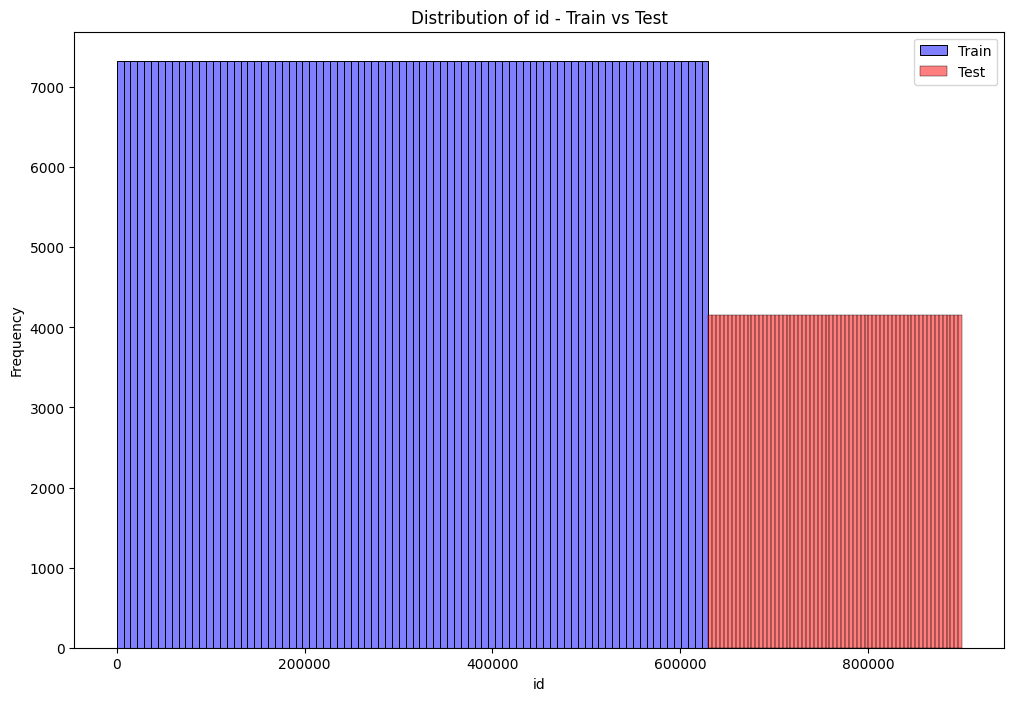

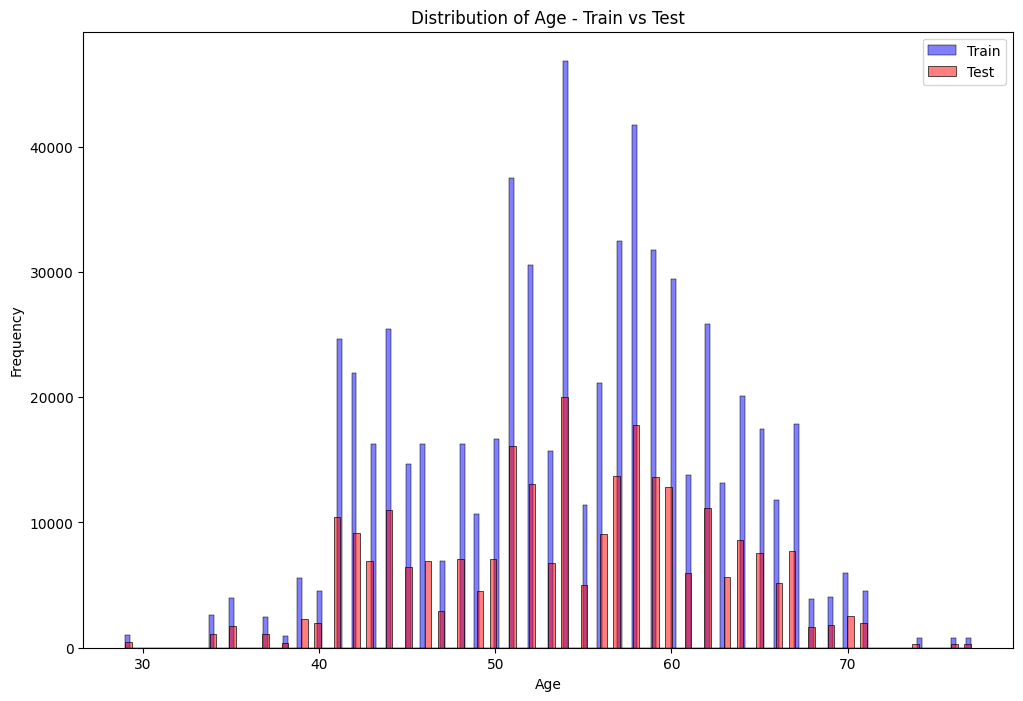

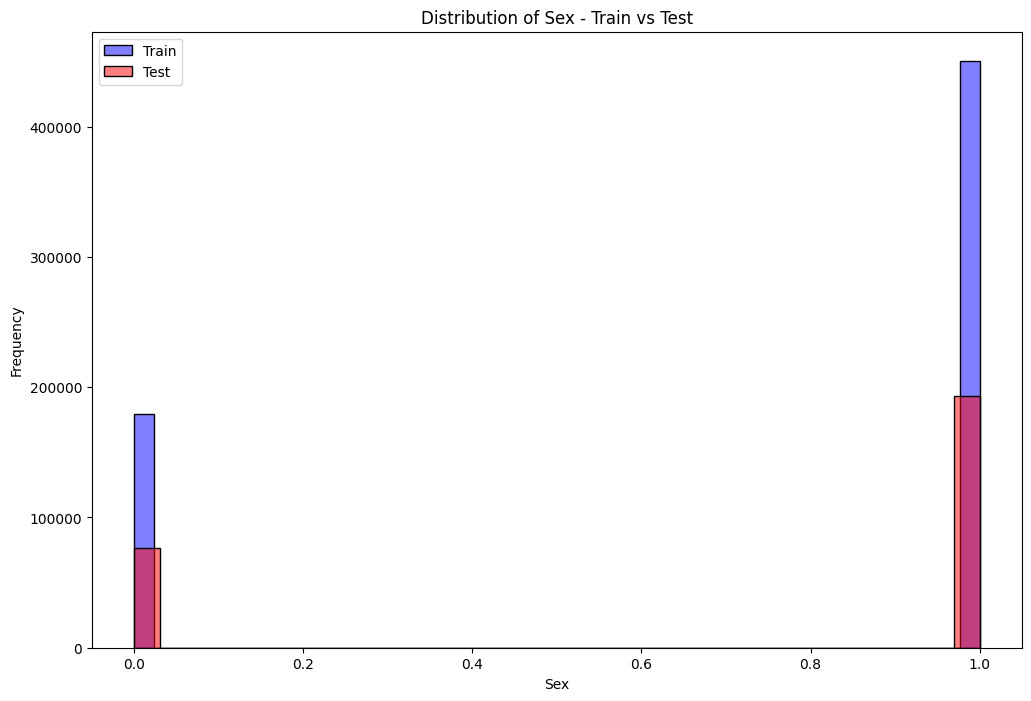

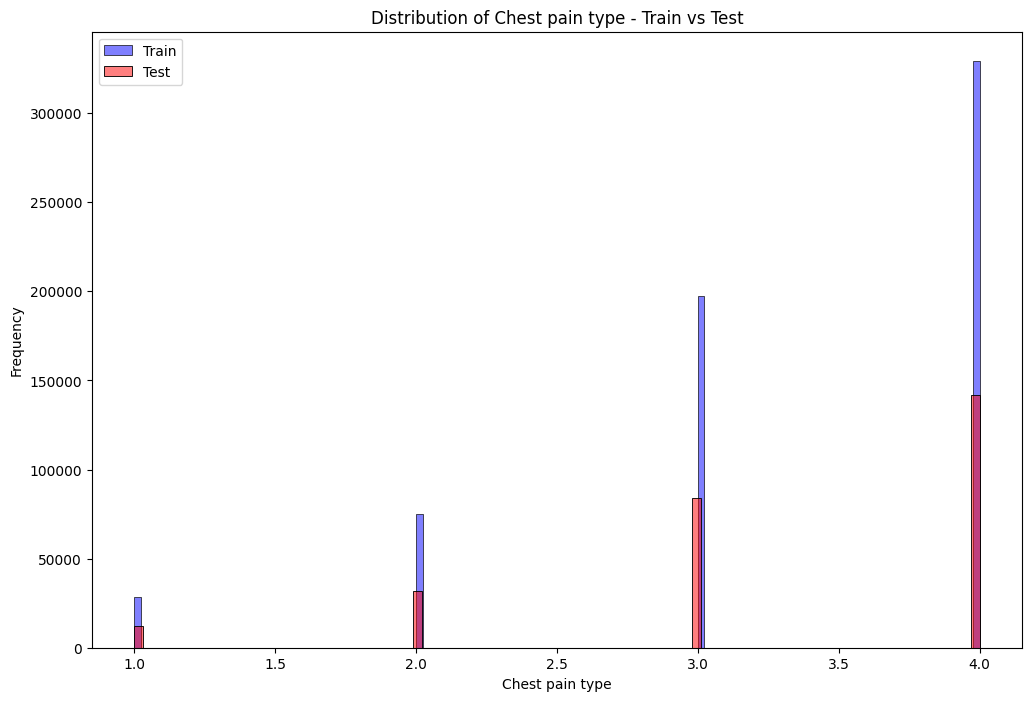

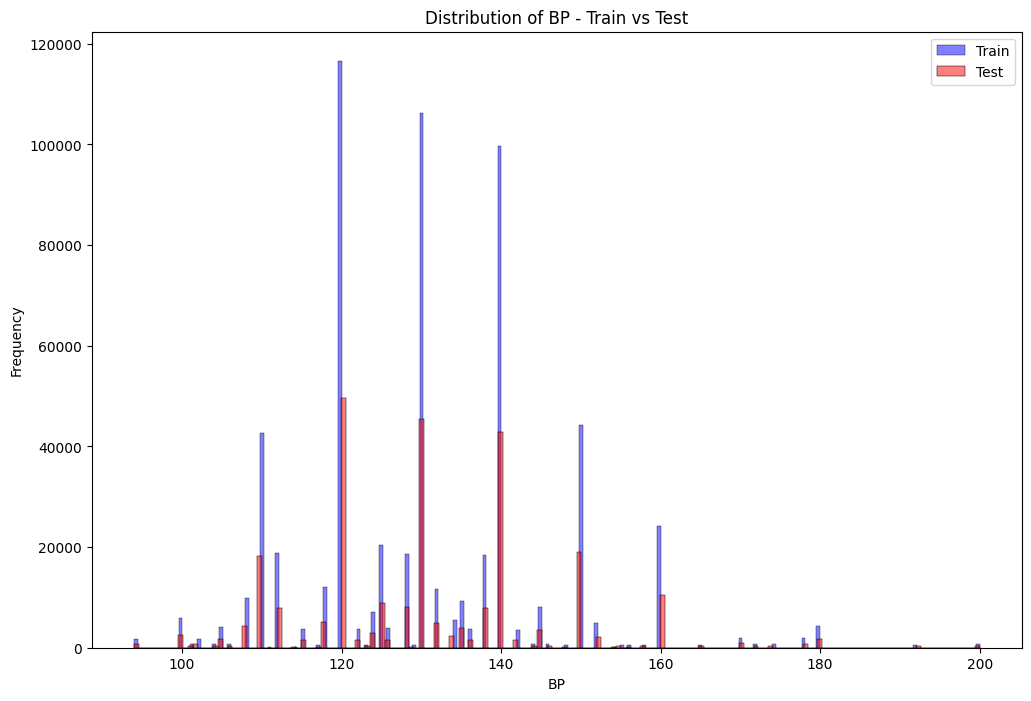

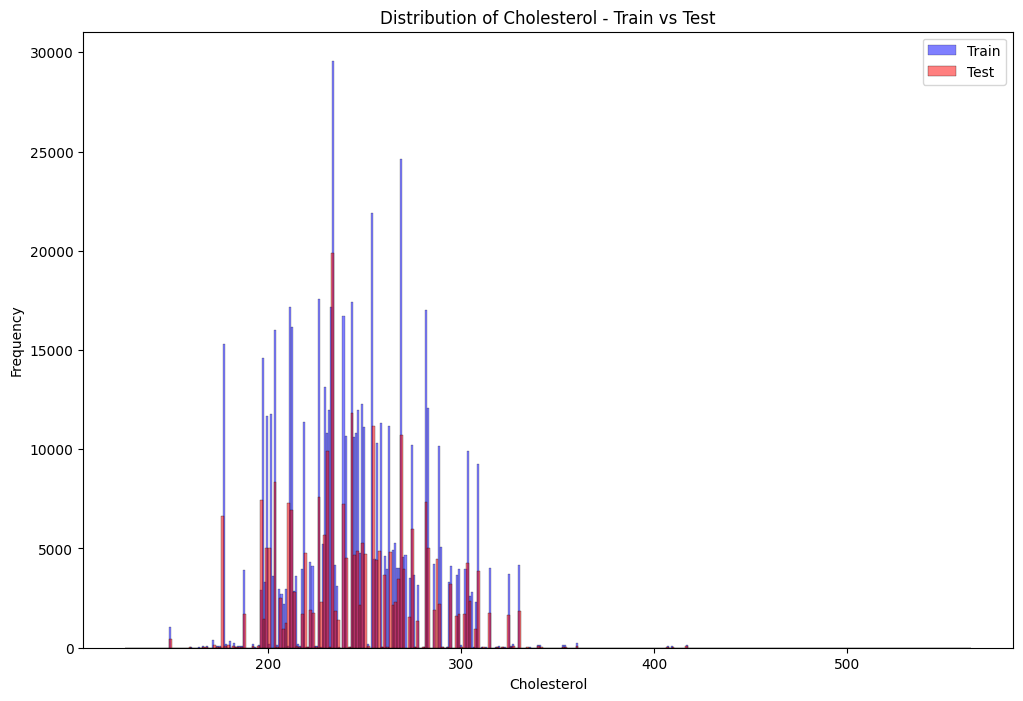

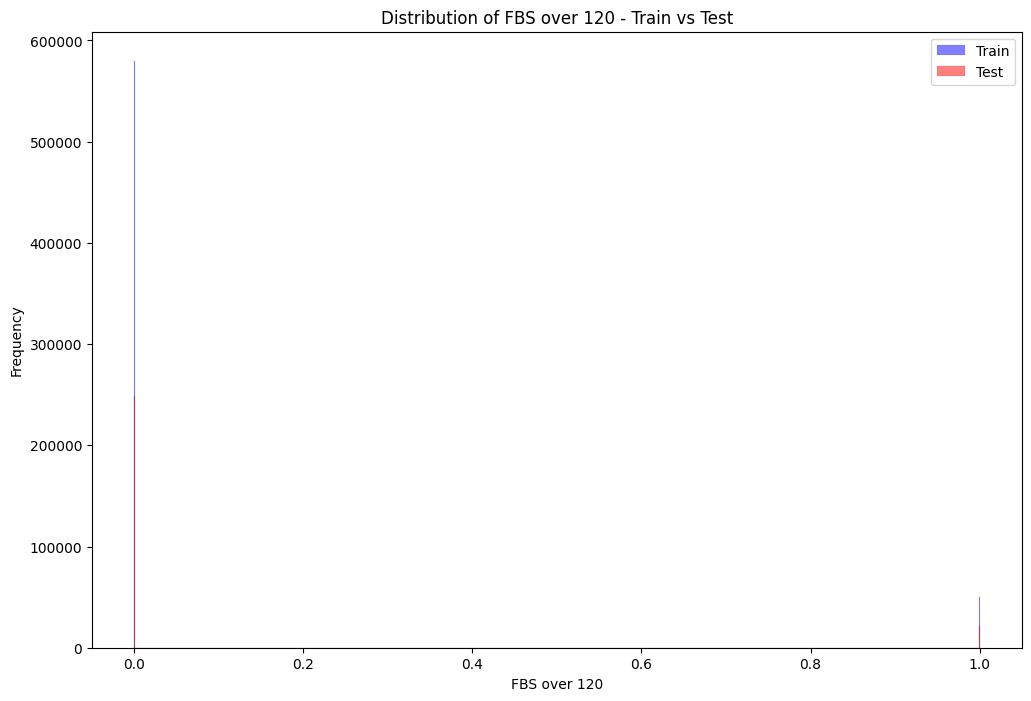

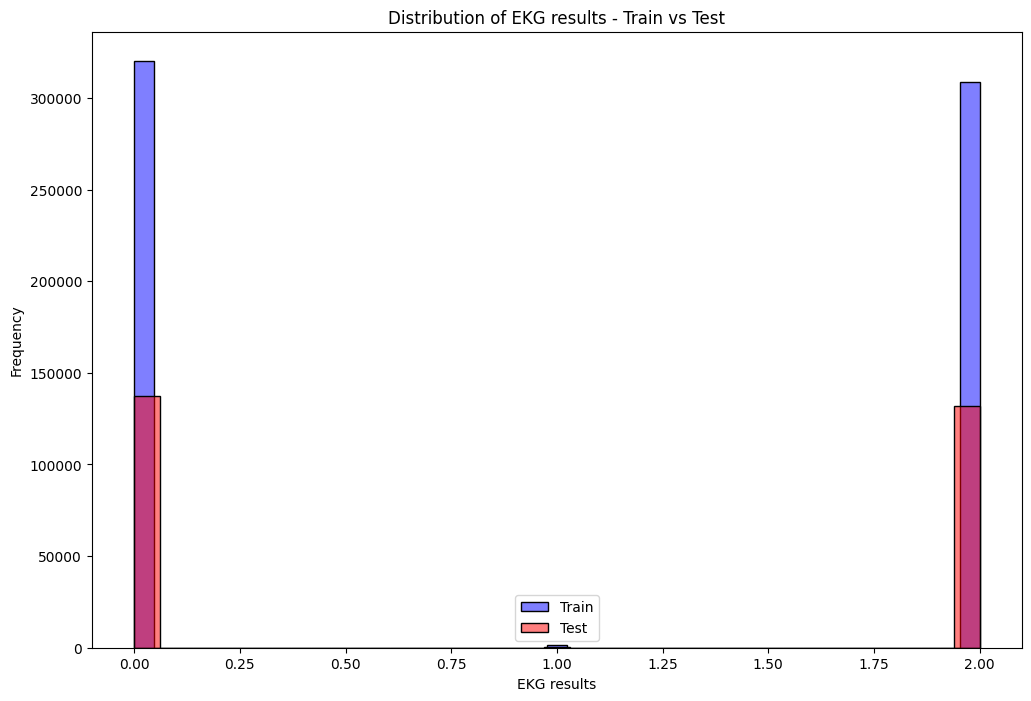

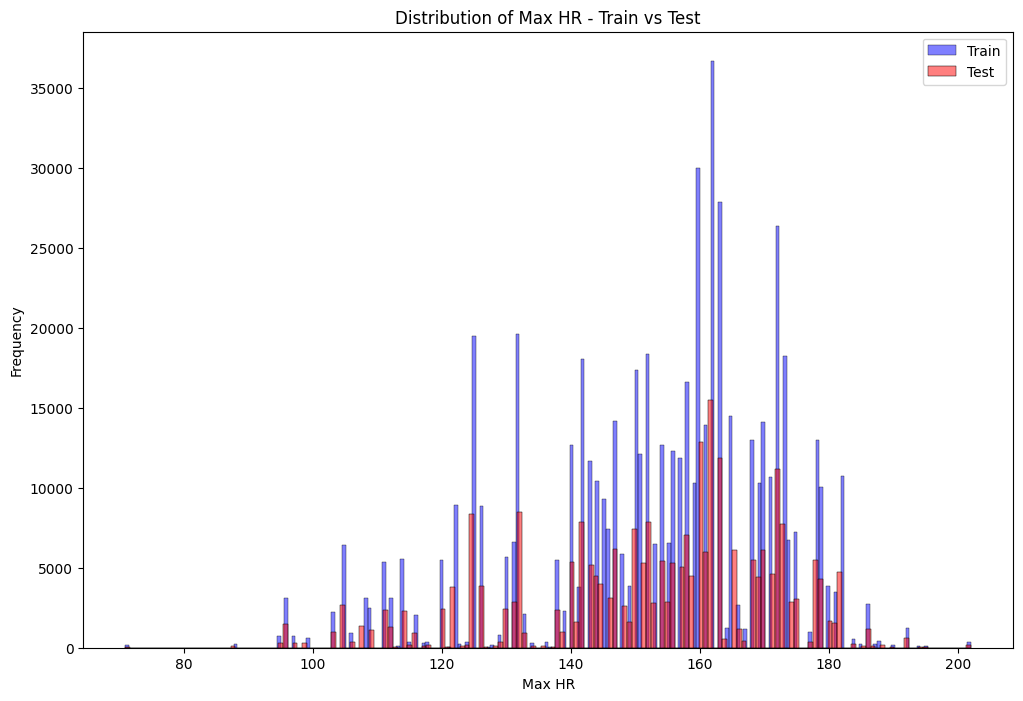

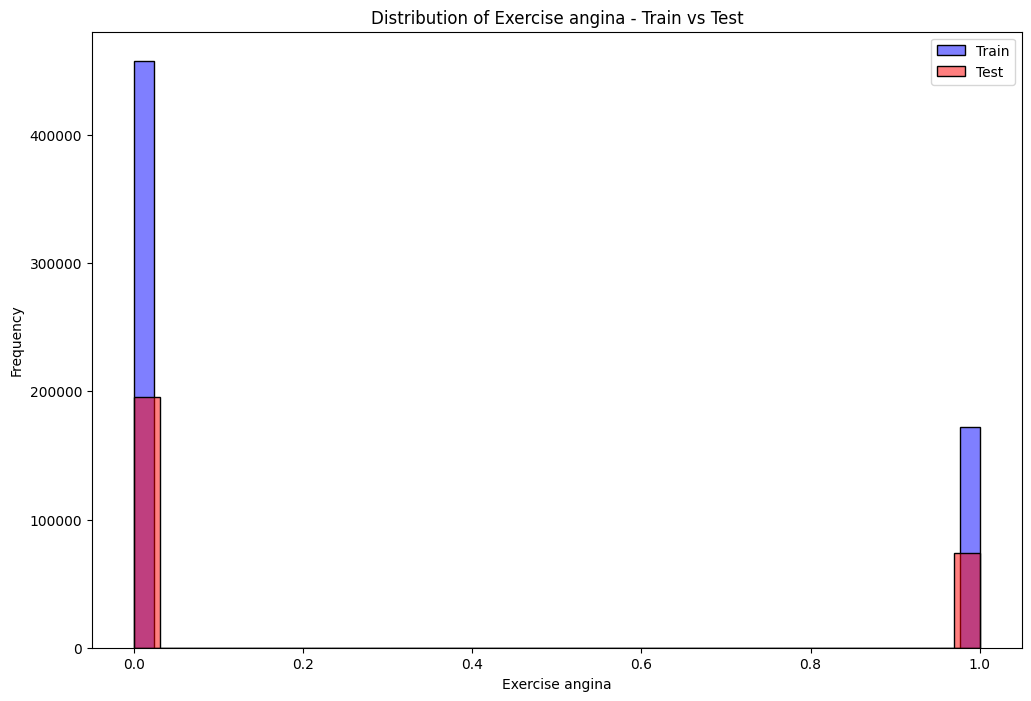

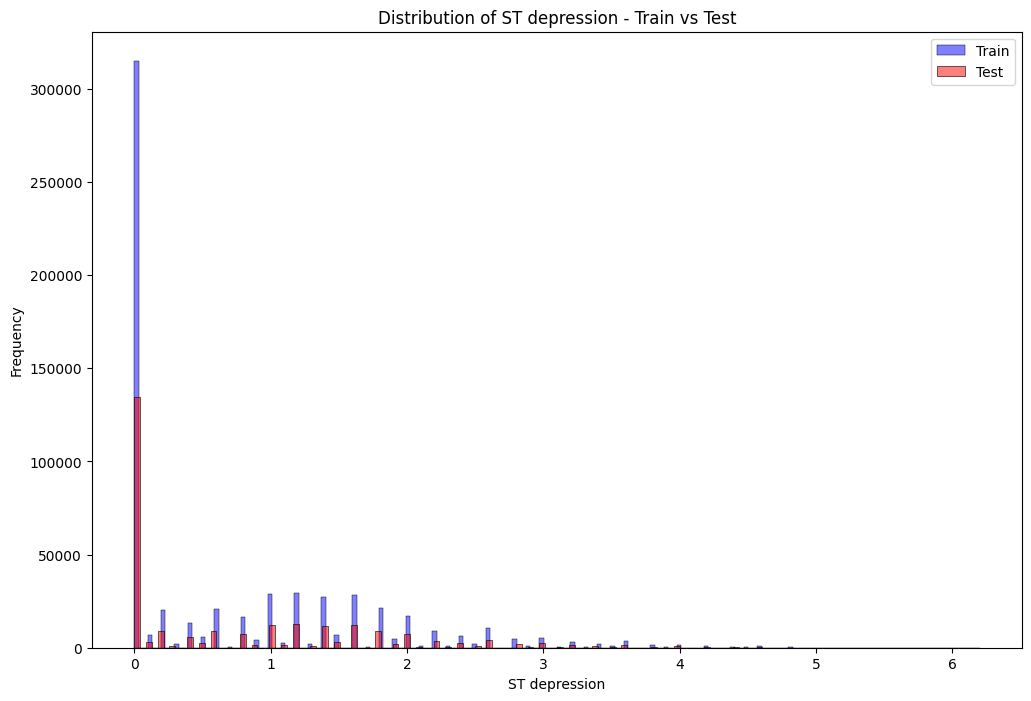

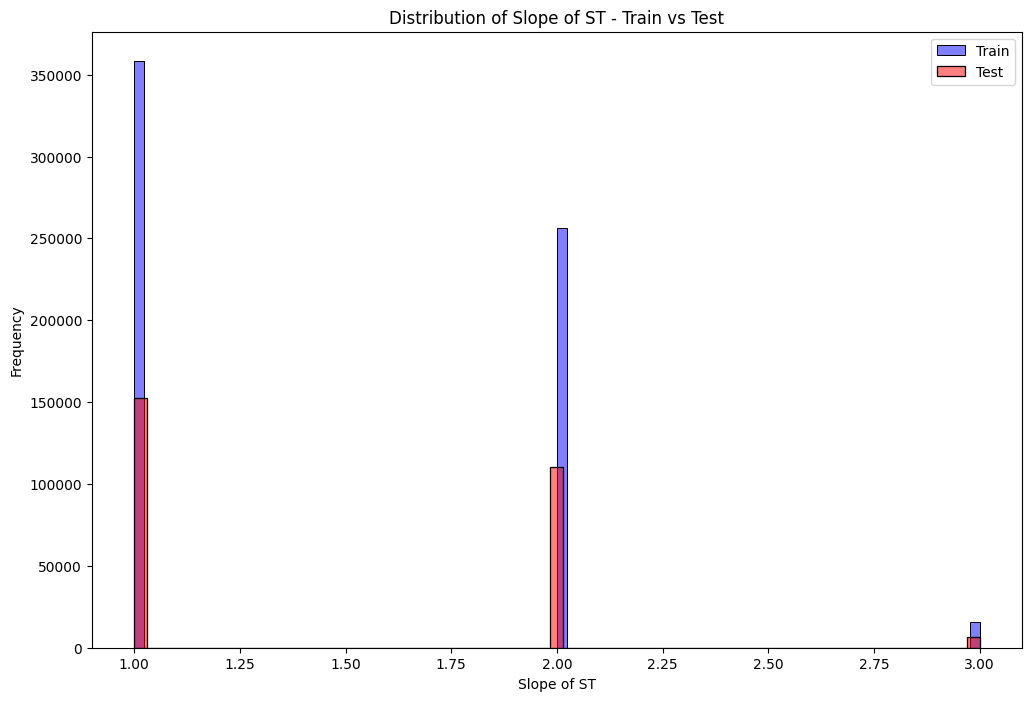

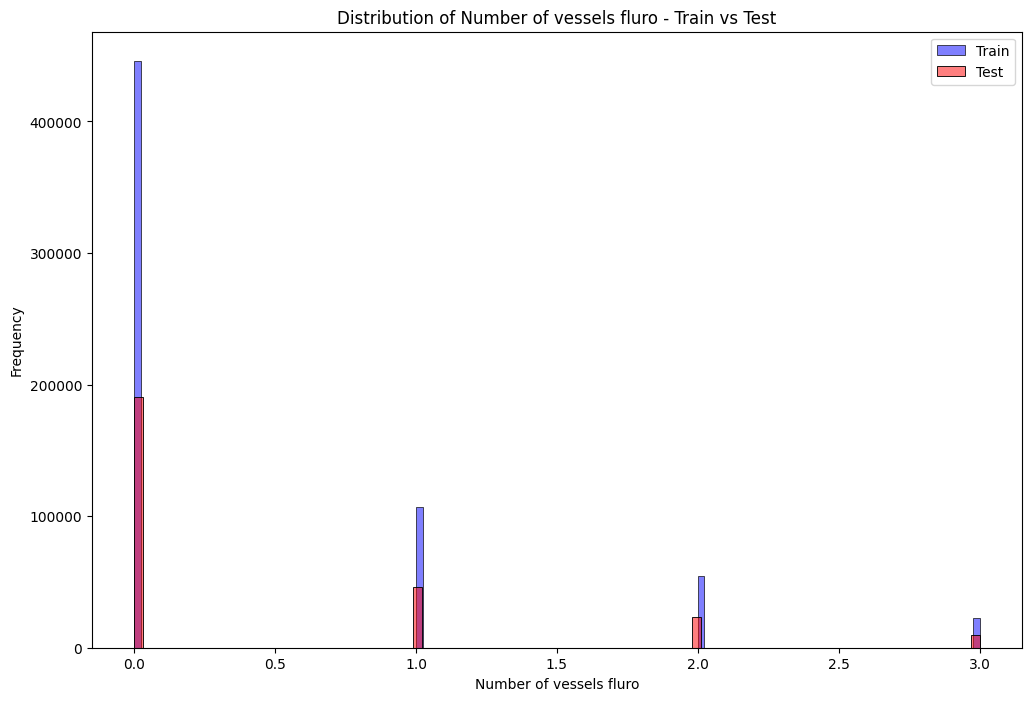

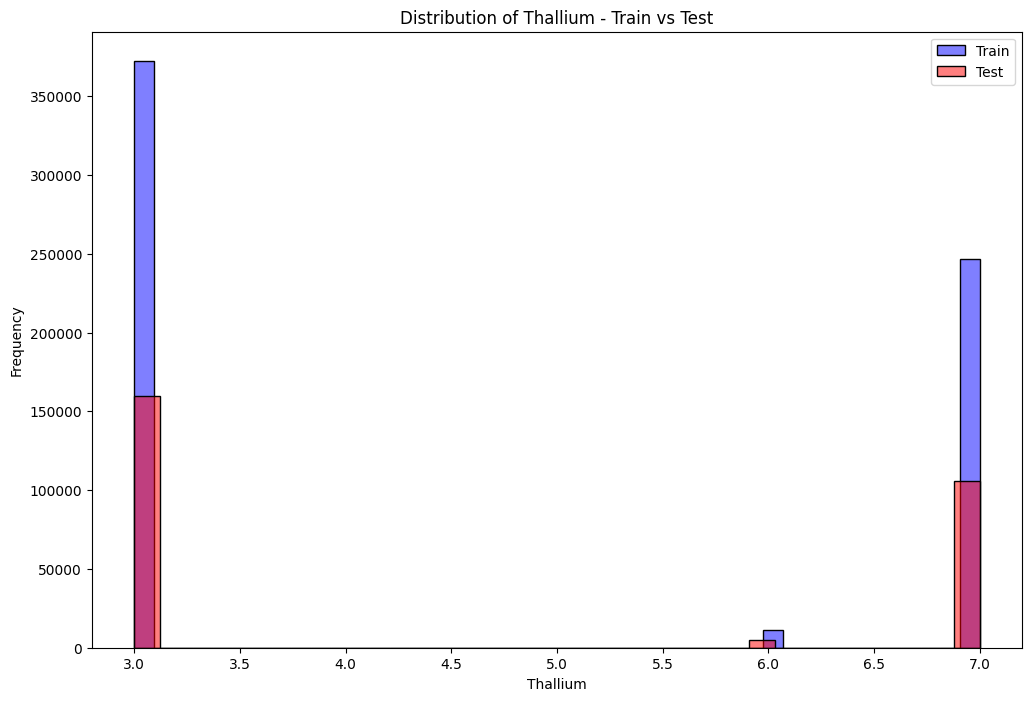

In [8]:
features = [col for col in train_df.select_dtypes(include='number').columns]

for feature in features:
    plt.figure(figsize=(12, 8))
    sns.histplot(train_df[feature], color='blue', label='Train', alpha=0.5)
    sns.histplot(test_df[feature], color='red', label='Test', alpha=0.5)
    plt.title(f'Distribution of {feature} - Train vs Test')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

Histogram mengkonfirmasi bahwa distribusi train dan test hampir identik untuk semua fitur. Beberapa pola distribusi yang perlu diperhatikan:
- Chest pain type: Distribusi sangat condong ke nilai 4 (asimptomatik). Perlu dipertimbangkan apakah ini perlu di-encode sebagai one-hot.
- ST depression: Right-skewed kuat.
- Cholesterol: Distribusi mendekati normal.
- Thallium: Distribusi multimodal (nilai 3, 6, 7), perlu perhatian apakah diperlakukan sebagai ordinal atau one-hot encoding.
- EKG results: Distribusi tidak merata (dominan 0 dan 2, sangat sedikit 1).

/tmp/ipykernel_15528/1644451791.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Train', 'Test'], patch_artist=True,


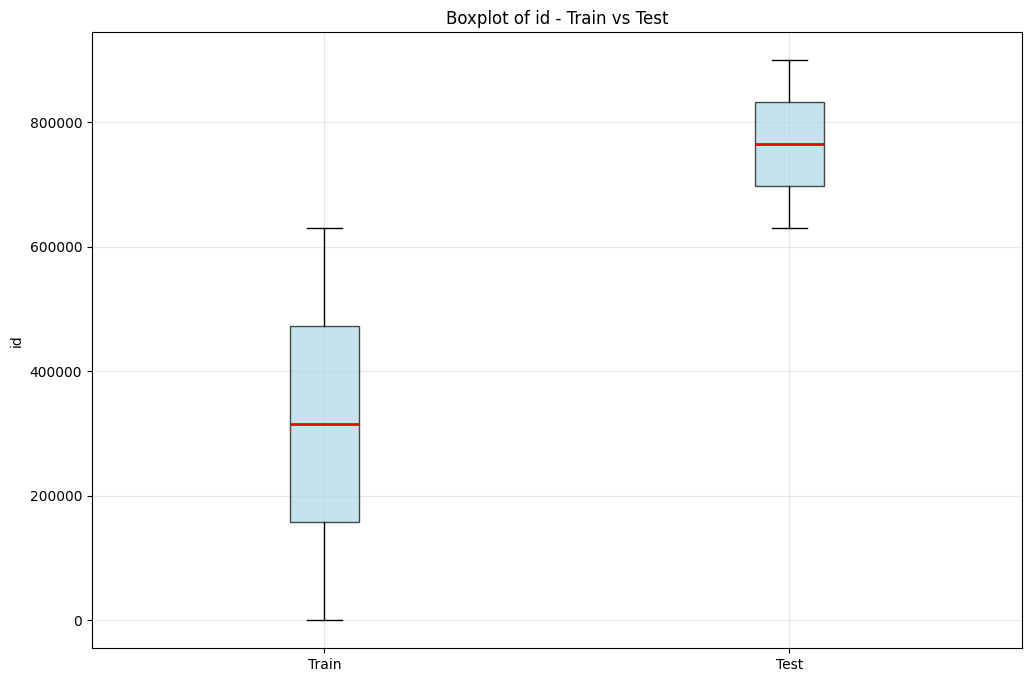

/tmp/ipykernel_15528/1644451791.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Train', 'Test'], patch_artist=True,


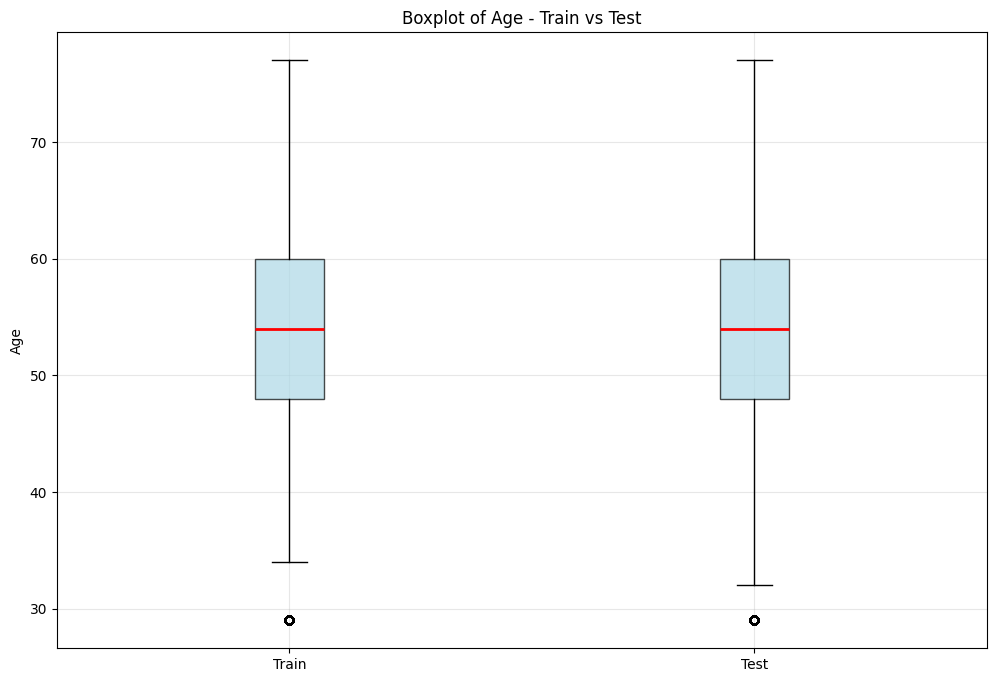

/tmp/ipykernel_15528/1644451791.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Train', 'Test'], patch_artist=True,


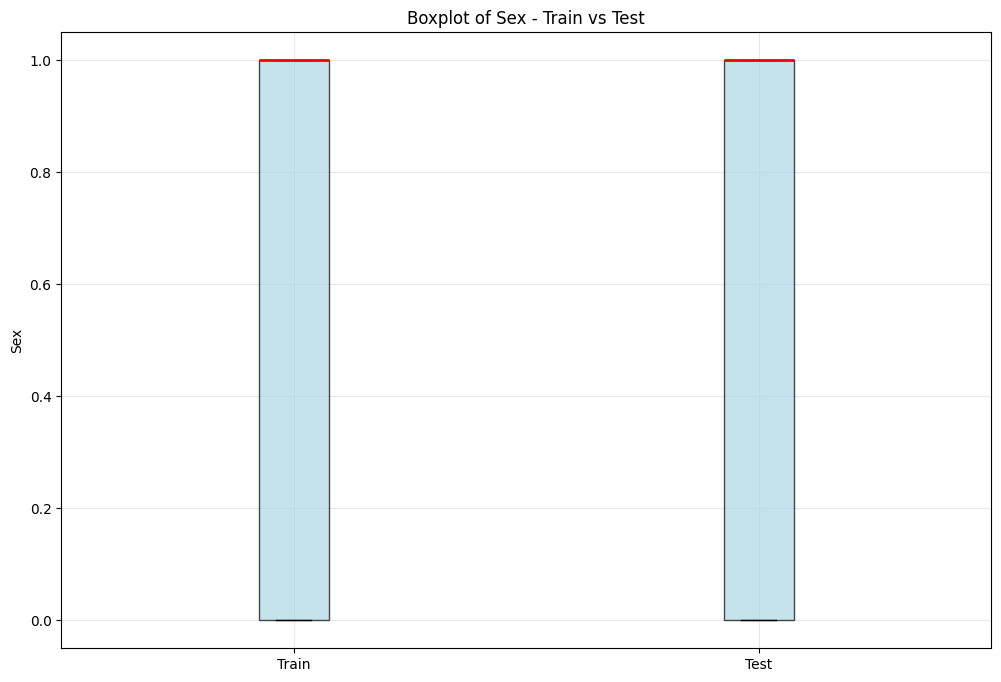

/tmp/ipykernel_15528/1644451791.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Train', 'Test'], patch_artist=True,


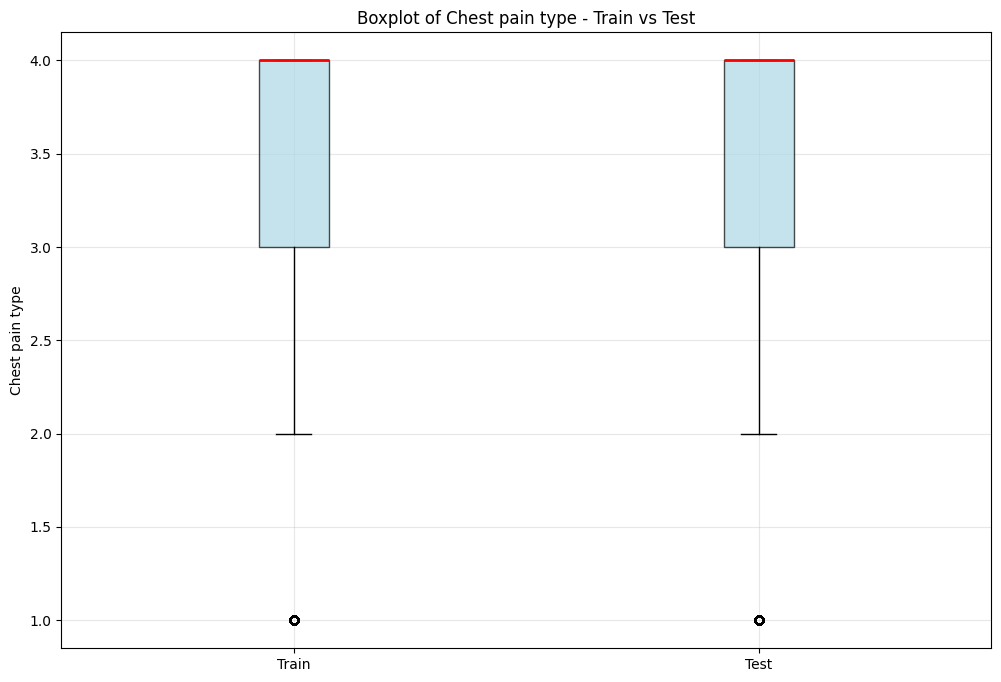

/tmp/ipykernel_15528/1644451791.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Train', 'Test'], patch_artist=True,


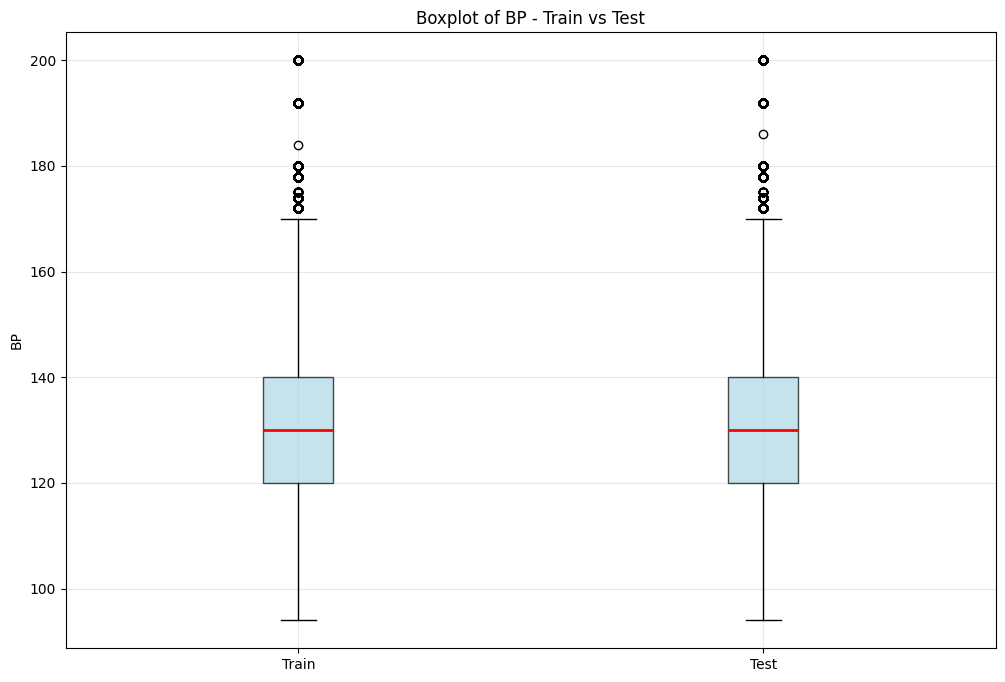

/tmp/ipykernel_15528/1644451791.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Train', 'Test'], patch_artist=True,


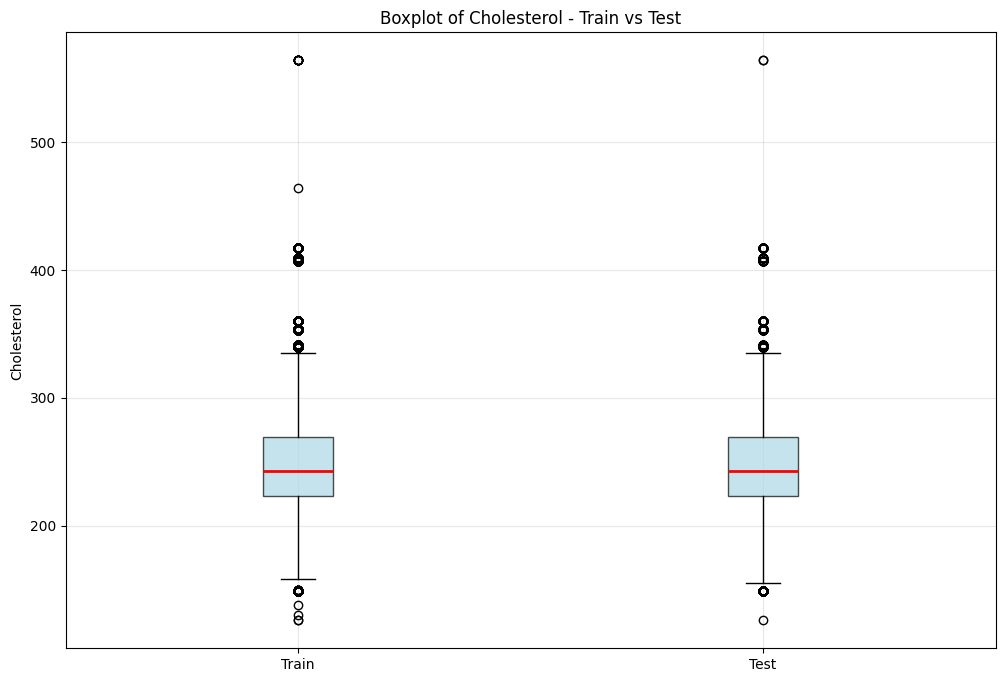

/tmp/ipykernel_15528/1644451791.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Train', 'Test'], patch_artist=True,


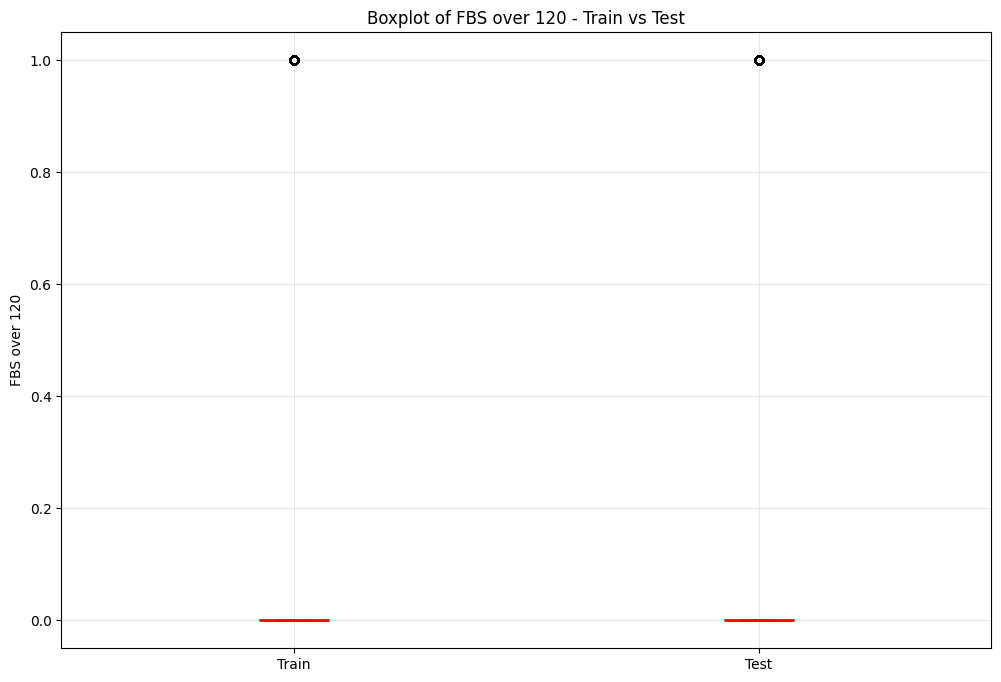

/tmp/ipykernel_15528/1644451791.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Train', 'Test'], patch_artist=True,


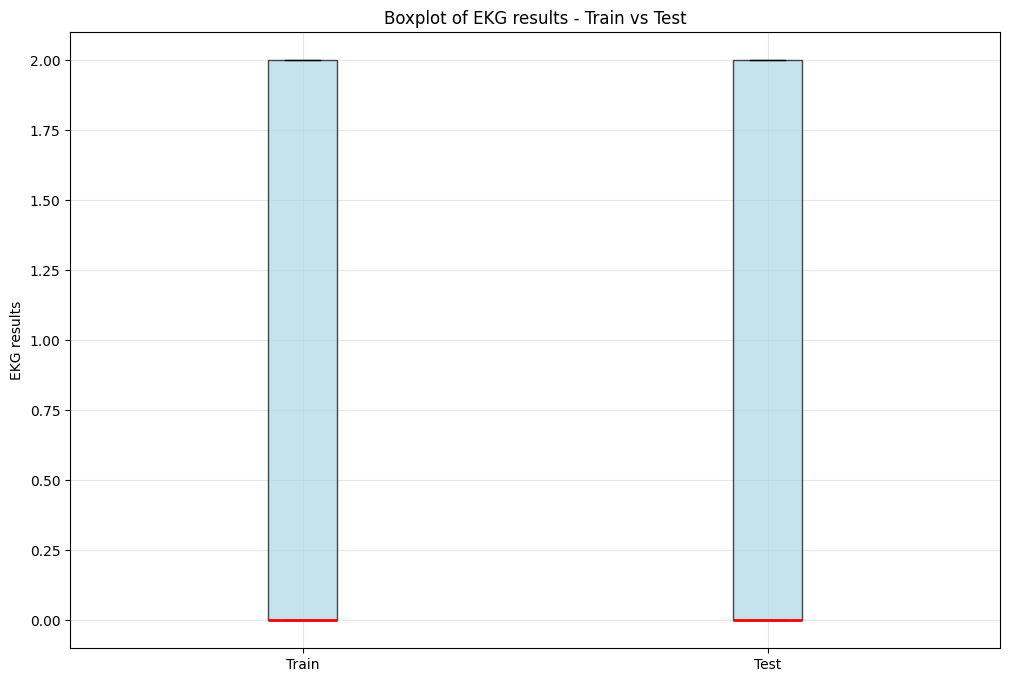

/tmp/ipykernel_15528/1644451791.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Train', 'Test'], patch_artist=True,


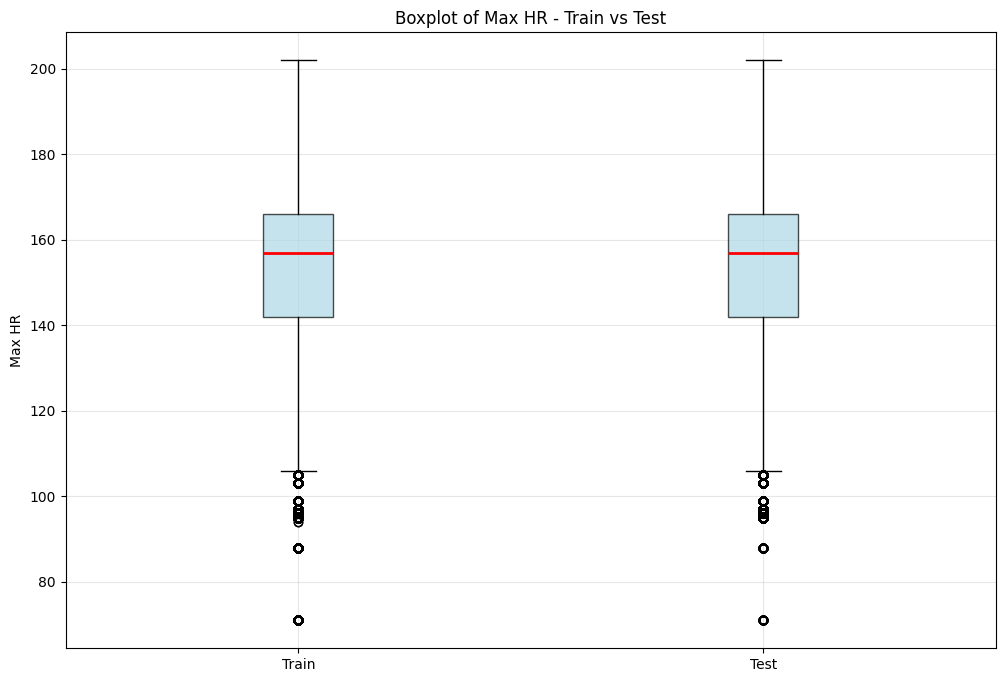

/tmp/ipykernel_15528/1644451791.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Train', 'Test'], patch_artist=True,


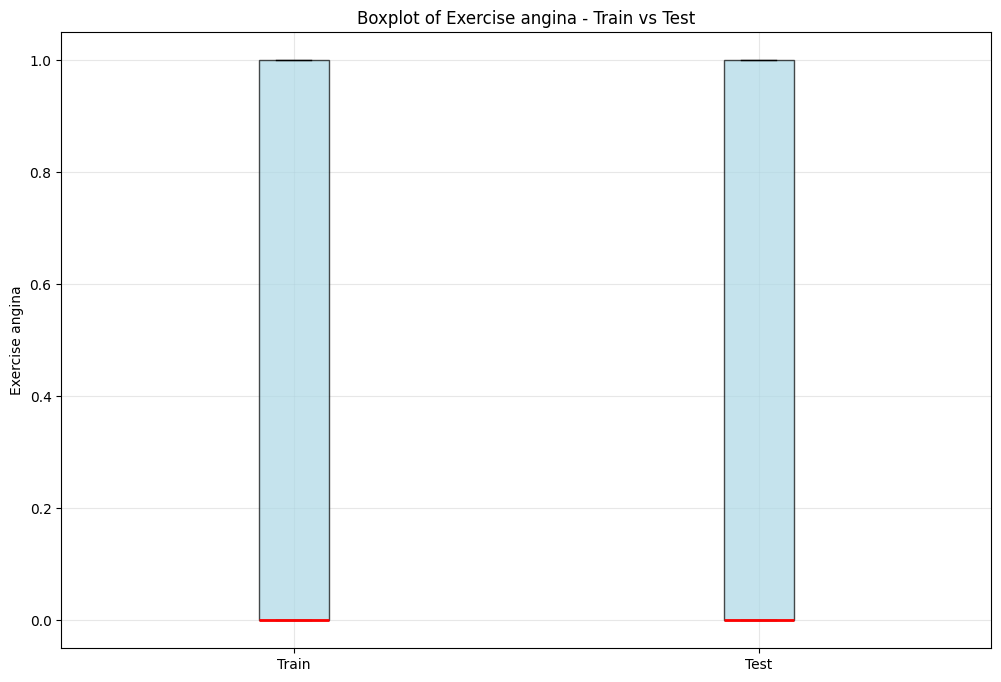

/tmp/ipykernel_15528/1644451791.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Train', 'Test'], patch_artist=True,


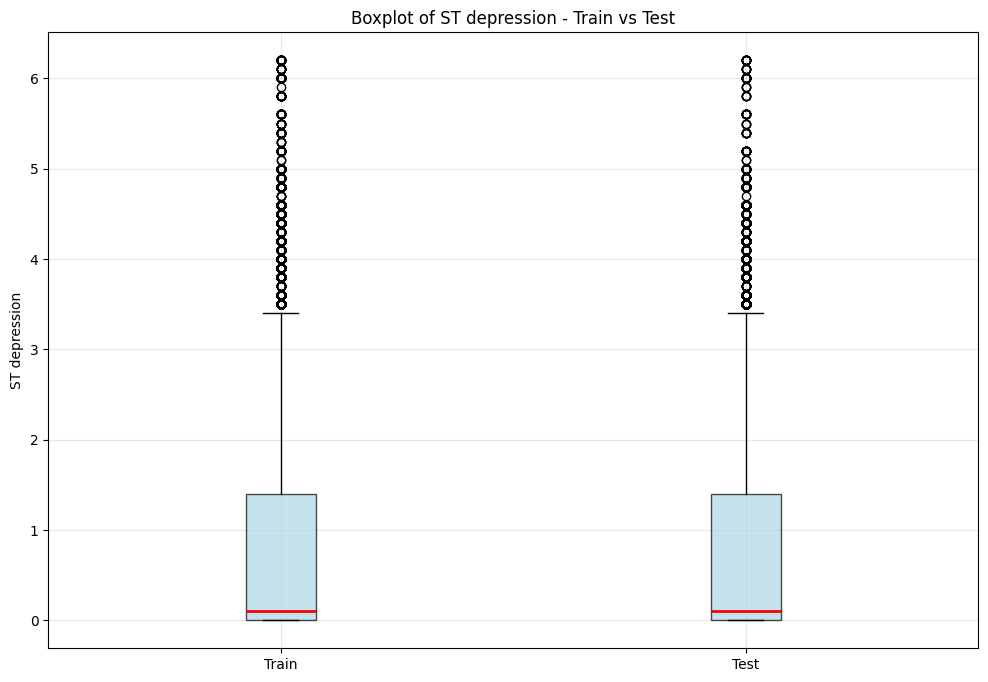

/tmp/ipykernel_15528/1644451791.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Train', 'Test'], patch_artist=True,


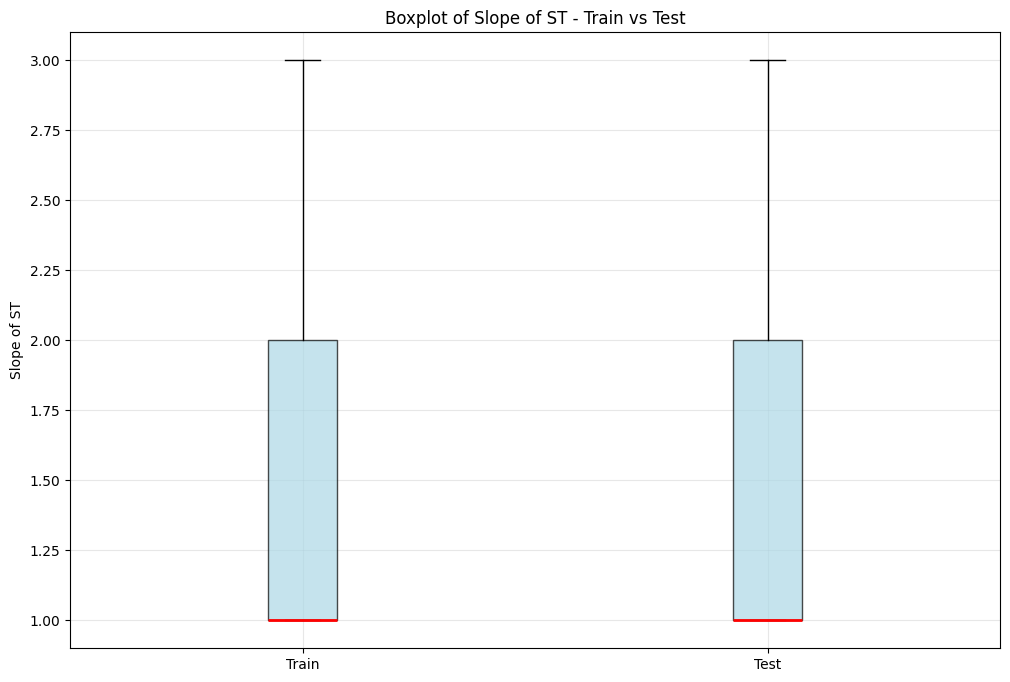

/tmp/ipykernel_15528/1644451791.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Train', 'Test'], patch_artist=True,


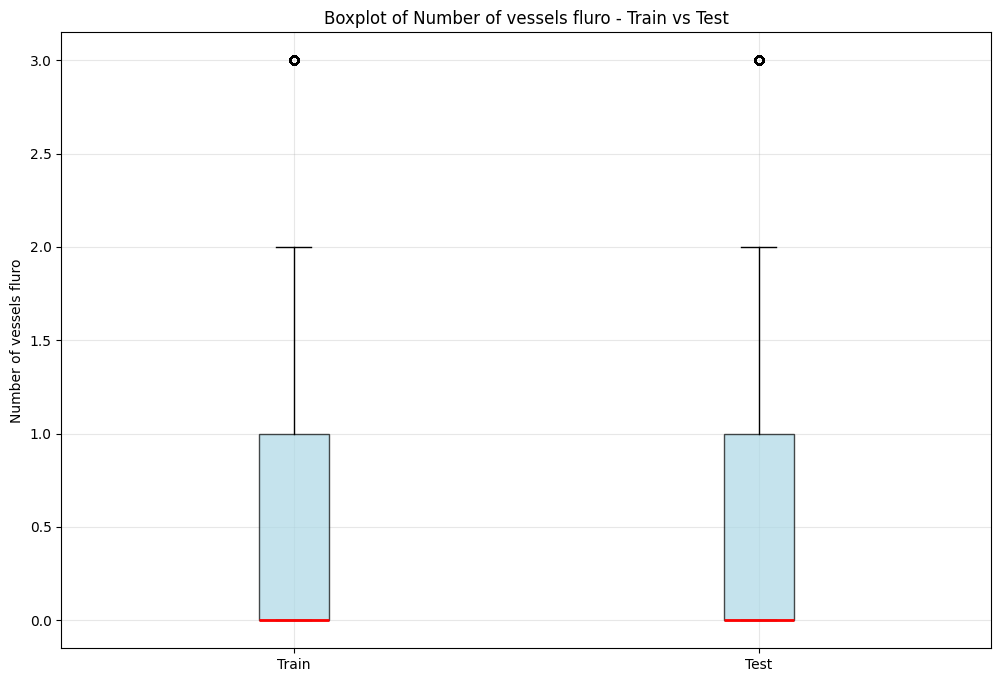

/tmp/ipykernel_15528/1644451791.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Train', 'Test'], patch_artist=True,


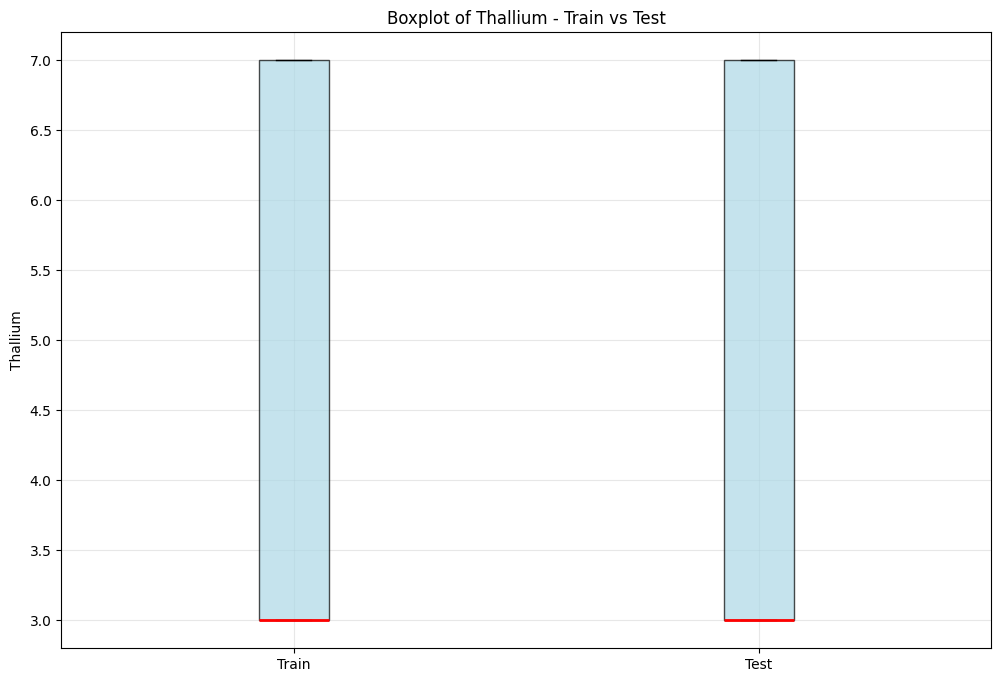

In [9]:
features = [col for col in train_df.select_dtypes(include='number').columns]
for feature in features:
    plt.figure(figsize=(12, 8))
    
    # Combine data for side-by-side boxplot
    data_to_plot = [train_df[feature].dropna(), test_df[feature].dropna()]
    
    plt.boxplot(data_to_plot, labels=['Train', 'Test'], patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
    
    plt.title(f'Boxplot of {feature} - Train vs Test')
    plt.ylabel(feature)
    plt.grid(True, alpha=0.3)
    plt.show()

- BP, Cholesterol, Max HR → Terdapat banyak outlier (titik di luar whisker), terutama di sisi atas. Ini relevan karena model sensitif terhadap outlier seperti KNN dan SVM akan sangat terdampak.
- ST depression → Median mendekati nol dengan banyak outlier di atas — distribusi sangat skewed, mengkonfirmasi observasi dari histogram.
- Age → Relatif simetris, outlier minimal.
- Number of vessels fluro → Median 0, dengan outlier hingga 3. Distribusi sangat condong ke kiri.
- Konsistensi train vs test → Semua boxplot train dan test hampir identik, kembali mengkonfirmasi tidak ada distributional shift.

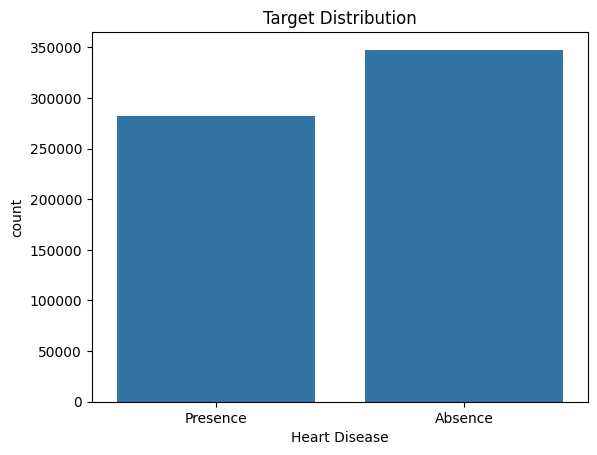

In [10]:
"""
(Optional) TODO: Tambahkan EDA lagi
"""
train_df[target].value_counts(normalize=True)

sns.countplot(data=train_df, x=target)
plt.title("Target Distribution")
plt.show()


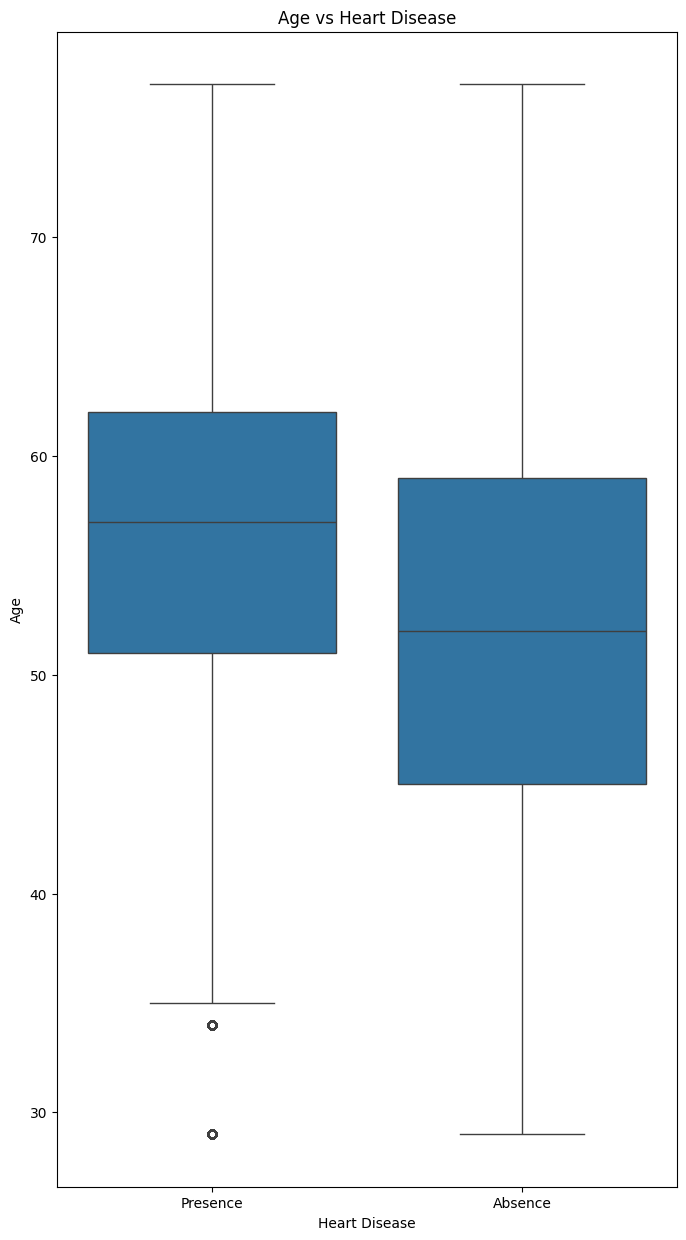

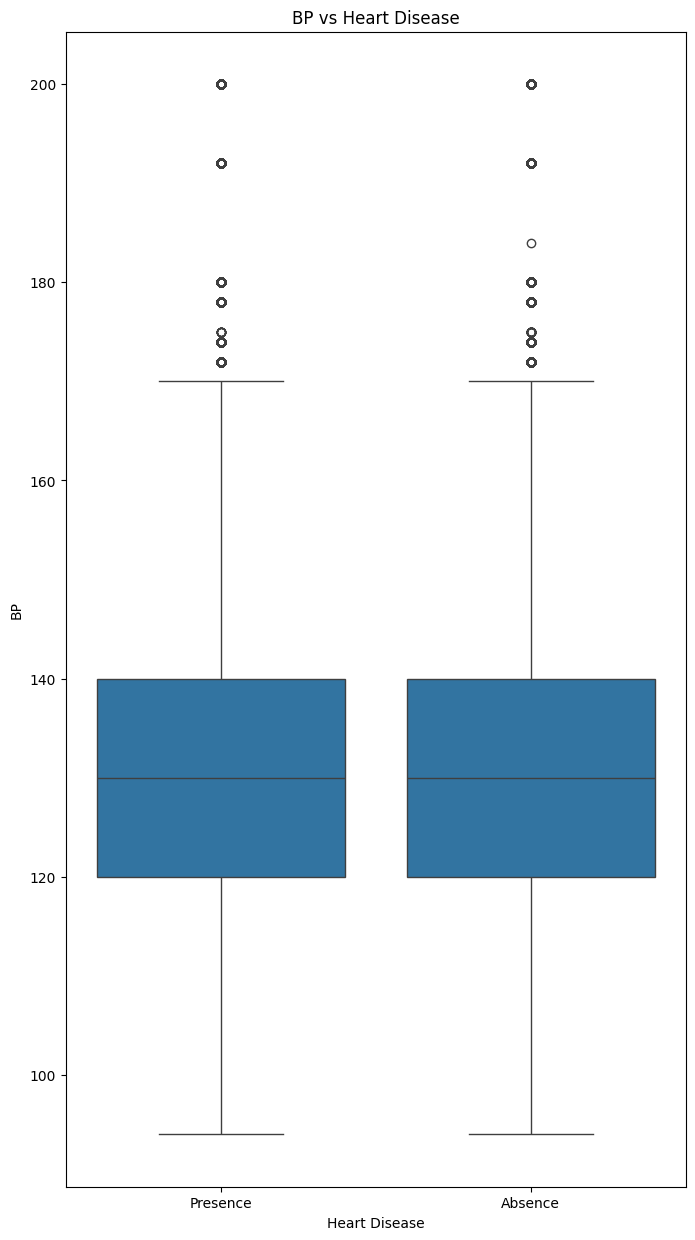

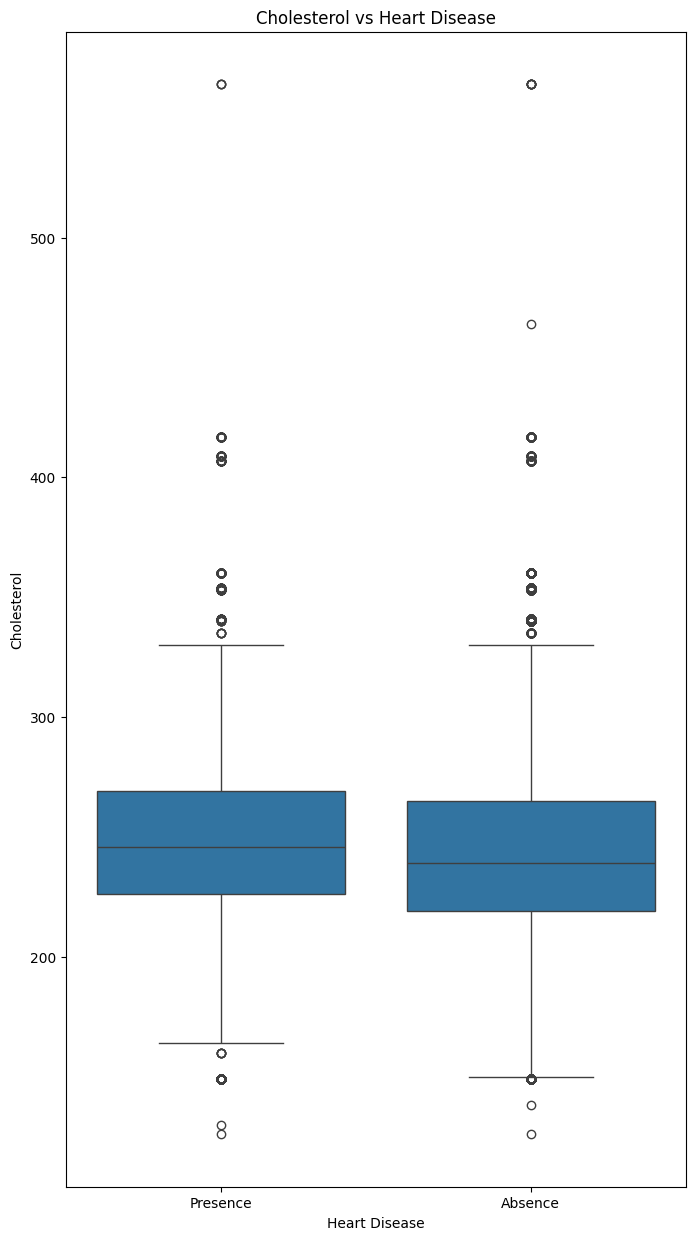

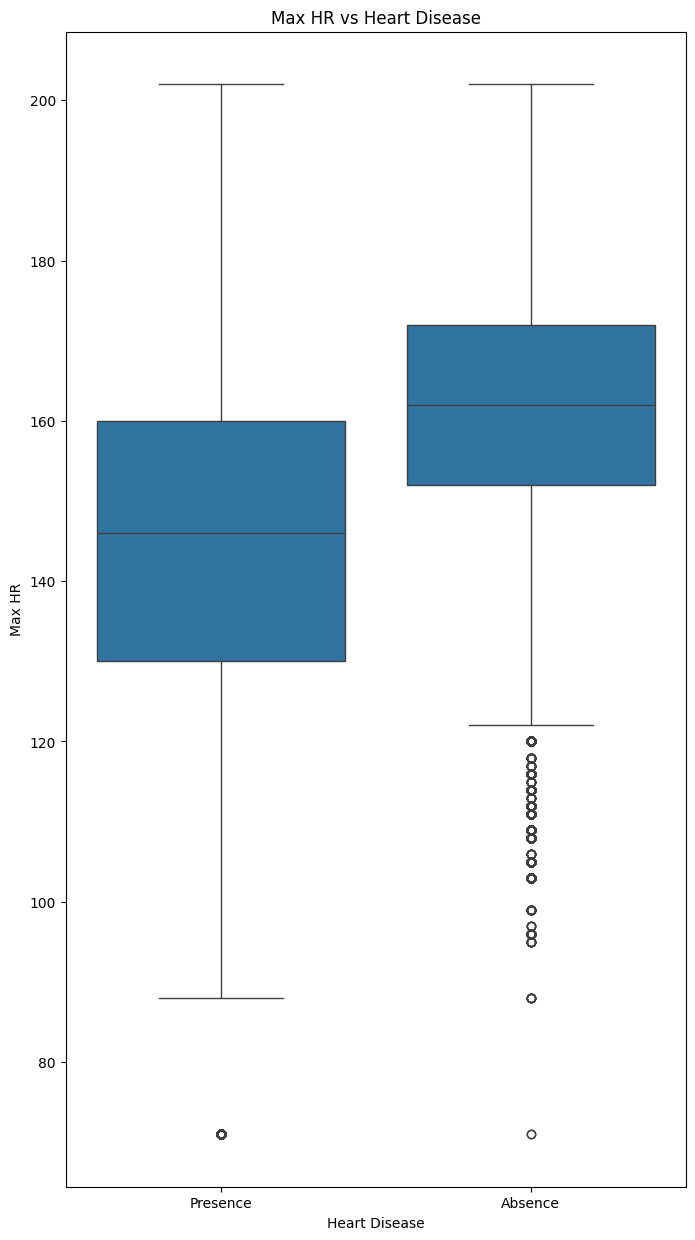

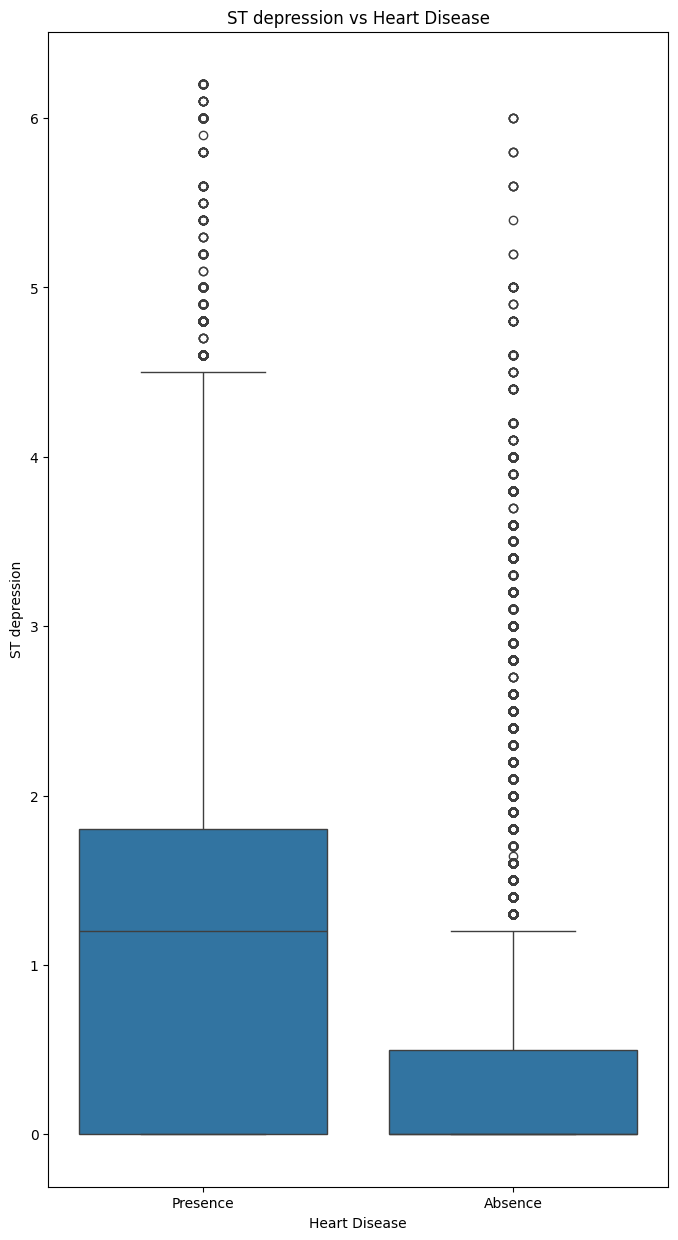

In [11]:
numerical_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

for cols in numerical_cols:
    plt.figure(figsize=(8, 15))
    sns.boxplot(data=train_df, x=target, y=cols)
    plt.title(f"{cols} vs {target}")
    plt.show()


Insight tambahan dari explorasi train data:
- 'presence' heart disease medianya lebih tinggi, yang berarti orang tua mungkin lebih berisiko, namun masih terlihat overlapping, sehingga age bukan penentu utama
- blood pressure antara 'presence' dan 'absence' sama, kemungkinan blood pressure memang tidak terlalu berpengaruh
- cholesterol juga terlihat perbandingannya mirip
- Max heart rate terlihat perbedaan median, mungkin berpengaruh.
- Median Presense pada depresi lebih tinggi dan persebaranya lebih banyak. 


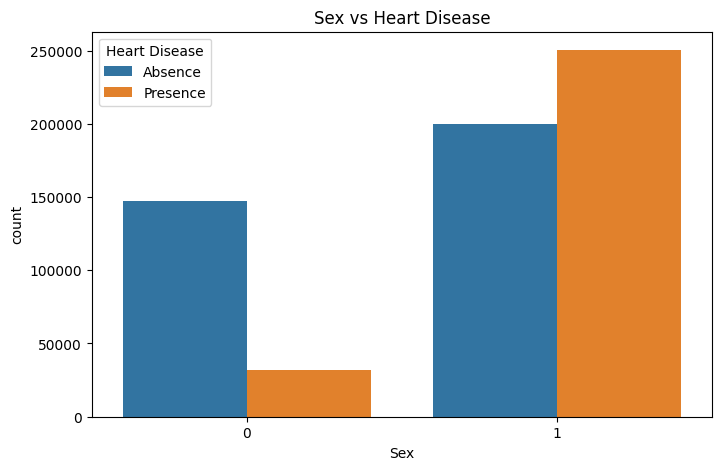

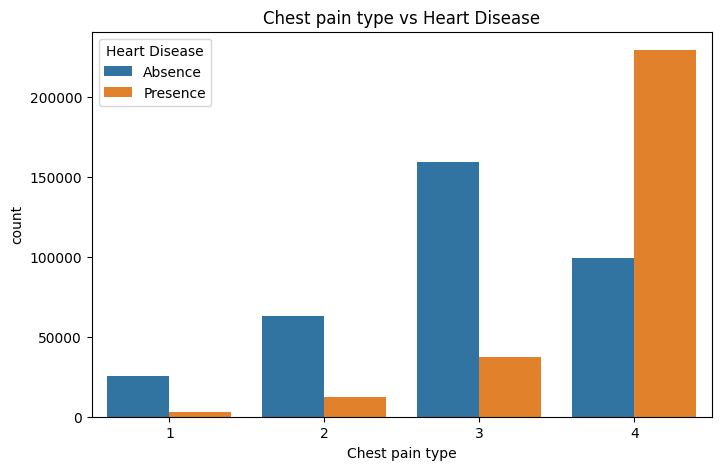

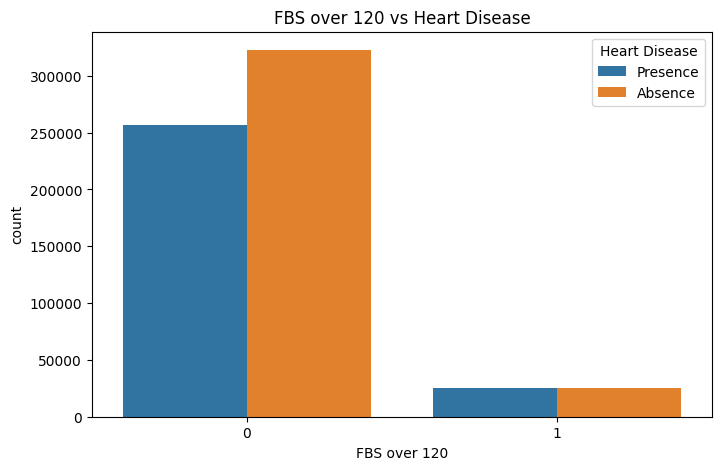

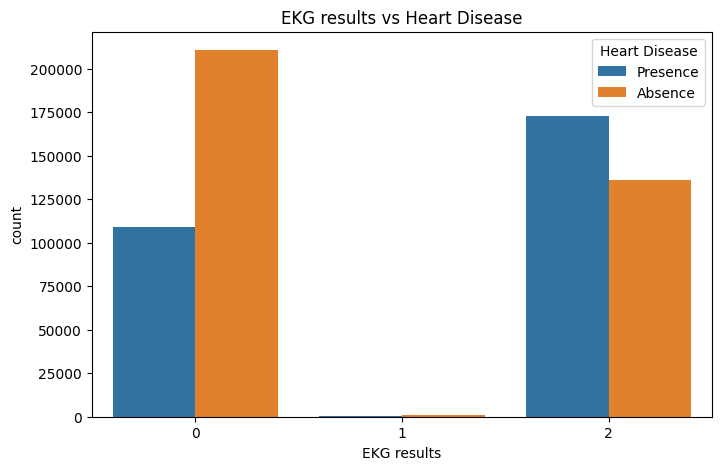

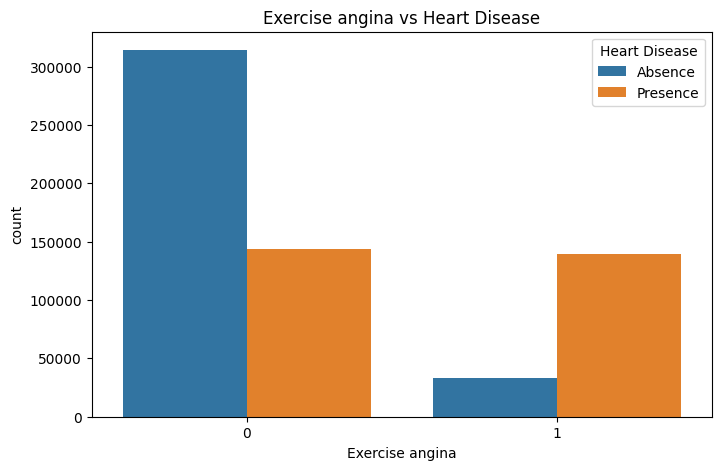

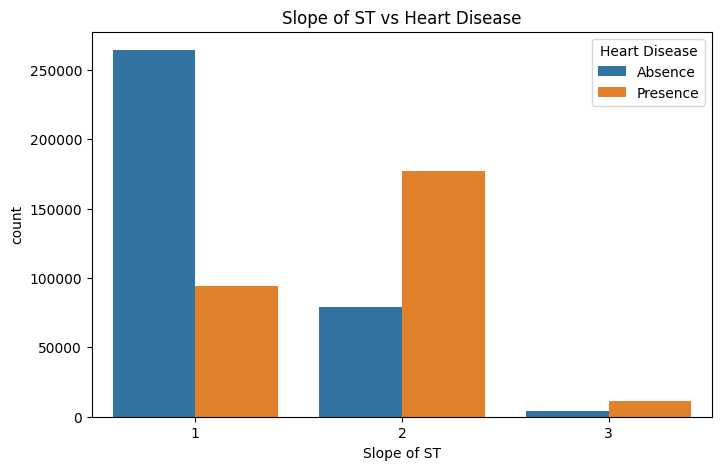

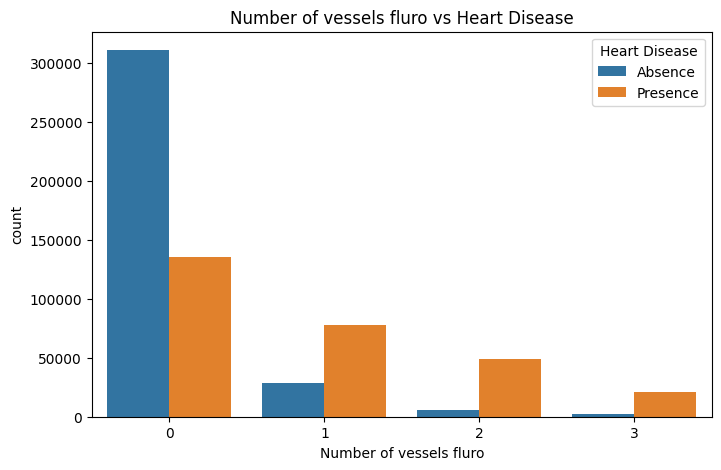

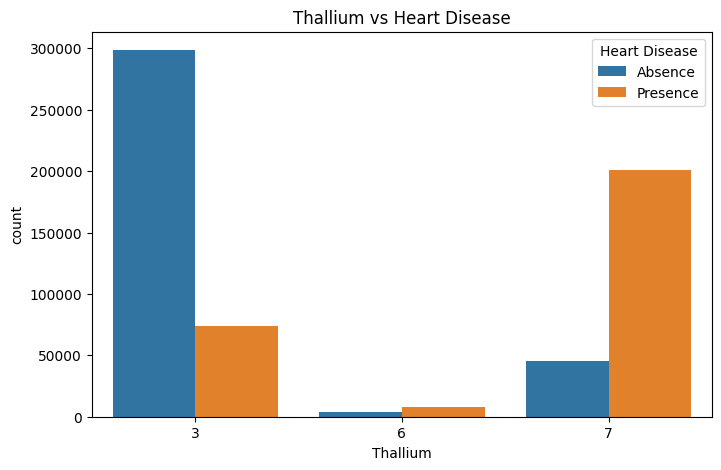

In [13]:
catagotical_cols = [
    'Sex', 'Chest pain type', 'FBS over 120', 'EKG results',
    'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium'
]

for col in catagotical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=train_df, x=col, hue=target)
    plt.title(f"{col} vs {target}")
    plt.show()

# Test Heatmap
Mencari korelasi antar fitur

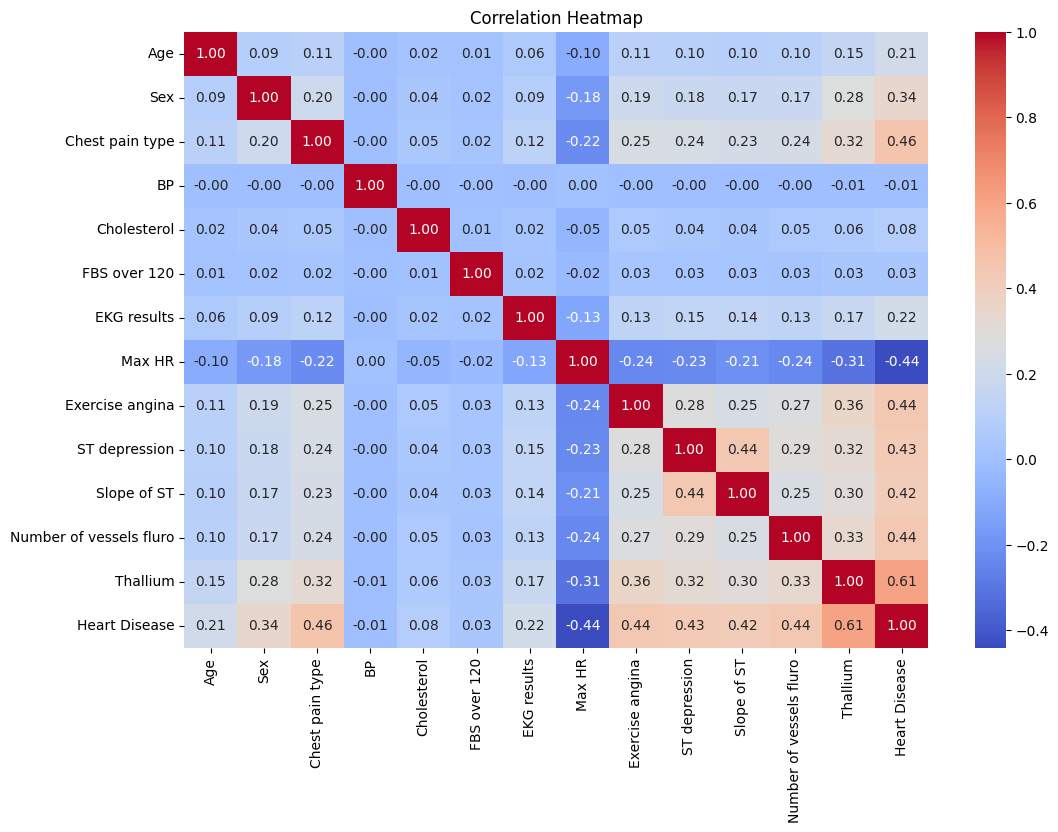

In [14]:
corelation_df = train_df.copy()

corelation_df["Heart Disease"] = corelation_df["Heart Disease"].map({"Absence" : 0, "Presence" : 1})
corr = corelation_df.drop(columns=["id"], errors="ignore").corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Jika berdasarkan Heatmap, terilihat bahwa thalium memiliki korelasi positif terbesar (0,61) diikuti oleh Chest Pain type (0,46) exercise angina, number of vessels fusso (0,44), ST depression (0,43), slope of ST (0,42) dan sex (0,34). kemungkinan fitur-fitur tersebutlah yang paling berpengaruh.

In [ ]:
outlier_summary = []

for col in numerical_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = train_df[
        (train_df[col] < lower_bound) | 
        (train_df[col] > upper_bound)
    ]
    
    outlier_summary.append({
        'Feature': col,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers),
        'Outlier Percentage': len(outliers) / len(train_df) * 100
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,Age,30.0,78.0,1048,0.166349
1,BP,90.0,170.0,9011,1.430317
2,Cholesterol,154.0,338.0,2194,0.348254
3,Max HR,106.0,202.0,14246,2.261270
4,ST depression,-2.1,3.5,9971,1.582698


# Data Preprocessing

- Drop kolom id dentifier
- Encode target Heart Disease Absence = 0, Presence = 1
- One-hot encode fitur kategorikal
- Scaling fitur numerik untuk model yang sensitif terhadap skala
- Pisahkan fitur X dan target y
- Split train-validation

In [ ]:
train_df

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7,Absence
629996,629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3,Absence
629997,629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7,Presence
629998,629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6,Presence


In [ ]:
"""
TODO: Apply data preprocessing to process the data based on the insight gain on EDA
"""

from sklearn.model_selection import train_test_split

# Drop id
X = train_df.drop(columns=['id', target])
y = train_df[target].map({"Absence" : 0, "Presence" : 1})

In [ ]:
numerical_cols

['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

In [ ]:
catagotical_cols

['Sex',
 'Chest pain type',
 'FBS over 120',
 'EKG results',
 'Exercise angina',
 'Slope of ST',
 'Number of vessels fluro',
 'Thallium']

Non ordinal -> one hot

# Modeling

In [ ]:
train_df['Heart Disease'].value_counts()

Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split

label2id = {
    'Absence': 0,
    'Presence': 1
}
id2label = {
    0: 'Absence',
    1: 'Presence'
}

train = train_df.drop(columns=[target])
test = test_df
y = train_df[target].map(label2id)

### For simplicity: I Only take 1% of data to train :D
sample_size = 0.01
train_sample, _, y_sample, _ = train_test_split(
    train, y, train_size=sample_size, random_state=random_state, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    train_sample, y_sample, test_size=0.2, random_state=random_state, stratify=y_sample
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=random_state),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=random_state),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=random_state),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, eval_metric='logloss', random_state=random_state),
    "CatBoost": CatBoostClassifier(iterations=100, learning_rate=0.1, verbose=0, random_state=random_state),
    "LightGBM": LGBMClassifier(n_estimators=100, learning_rate=0.1, verbose=-1, random_state=random_state),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', probability=True, random_state=random_state)
}
def evaluate_model(model, X_train, X_val, y_train, y_val):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    metrics = {
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred, average='weighted'),
        'Recall': recall_score(y_val, y_pred, average='weighted'),
        'F1 Score': f1_score(y_val, y_pred, average='weighted')
    }
    return metrics

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
results_unscaled = []

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    metrics = evaluate_model(model, X_train, X_val, y_train, y_val)
    metrics['Model'] = model_name
    metrics['Data_Type'] = 'Unscaled'
    results_unscaled.append(metrics)
    
    # Print results
    print(f"  Accuracy:  {metrics['Accuracy']:.4f}")
    print(f"  Precision: {metrics['Precision']:.4f}")
    print(f"  Recall:    {metrics['Recall']:.4f}")
    print(f"  F1 Score:  {metrics['F1 Score']:.4f}")


Training Logistic Regression...


c:\Users\Akmal Yusuf\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Accuracy:  0.8944
  Precision: 0.8956
  Recall:    0.8944
  F1 Score:  0.8939

Training Naive Bayes...
  Accuracy:  0.7190
  Precision: 0.7278
  Recall:    0.7190
  F1 Score:  0.7098

Training Decision Tree...
  Accuracy:  0.8190
  Precision: 0.8188
  Recall:    0.8190
  F1 Score:  0.8187

Training Random Forest...
  Accuracy:  0.8786
  Precision: 0.8787
  Recall:    0.8786
  F1 Score:  0.8783

Training XGBoost...
  Accuracy:  0.8913
  Precision: 0.8913
  Recall:    0.8913
  F1 Score:  0.8910

Training CatBoost...
  Accuracy:  0.8952
  Precision: 0.8955
  Recall:    0.8952
  F1 Score:  0.8949

Training LightGBM...
  Accuracy:  0.8857
  Precision: 0.8860
  Recall:    0.8857
  F1 Score:  0.8854

Training KNN...
  Accuracy:  0.5135
  Precision: 0.5121
  Recall:    0.5135
  F1 Score:  0.5127

Training SVM...
  Accuracy:  0.5516
  Precision: 0.3042
  Recall:    0.5516
  F1 Score:  0.3922


c:\Users\Akmal Yusuf\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Modeling Analysis

In [ ]:
"""
TODO: Lakukan analisis dari hasil performa model
"""

'\nTODO: Lakukan analisis dari hasil performa model\n'

# Question :D

Berikut adalah pertanyaan yang harus dijawab
1. Berdasarkan Hasil Eksplorasi Data yang telah dilakukan, Apa langkah Preprocessing yang perlu dilakukan? Mengapa hal tersebut perlu dilakukan?
2. Setelah mengaplikasikan tahapan Data Preprocessing, apakah terdapat pengaruh terhadap hasil pemodelan? Berikan pendapat anda terkait hal tersebut
3. Dari metrik yang digunakan pada saat pemodelan (training & evaluasi), apakah penggunaan metrik tersebut sudah tepat untuk studi kasus yang diberikan? Adakah metrik yang perlu diberikan perhatian khusus untuk studi kasus ini? Mengapa demikian?
4. Dari hasil eksperimen, model apa yang memiliki performa paling baik dan pada scenario apa hal tersebut dapat tercapai?
5. Apa insight yang didapat setelah melakukan pemodelan?

1. Terdapat beberapa langkah preprocessing yang perlu dilakukan alasan utamanya adalah menyesuaikan dengan beberapa model yang akan kita gunakan.